In [1]:
# !pip install numpy tensorflow sklearn

In [2]:
import os
import time
import json
import requests

start_id = 8606377926
request_limit = 1000
request_number = 20
cache_file = f"Data_{request_limit * request_number}.json"


if os.path.exists(cache_file):
    print(f"Using cache: {cache_file}")
    with open(cache_file, "r") as f:
        data = json.load(f)
else:
    data = []
    for i in range(request_number):
        if i > 0:
            time.sleep(1)
        req = (
            "https://api.opendota.com/api/explorer?sql="
            "SELECT matches.match_id, matches.radiant_win, matches.teamfights "
            "FROM matches "
            "WHERE matches.teamfights IS NOT NULL "
            f"AND matches.match_id <= {start_id}"
            "ORDER BY matches.match_id DESC "
            f"LIMIT {request_limit} OFFSET {i * request_limit}"
        )
        response = requests.get(req)
        print(f"{i + 1}: {response}")
        response.raise_for_status()
        data.extend(response.json()["rows"])
        with open(cache_file, "w") as f:
            json.dump(data, f)

Using cache: Data_20000.json


In [3]:
dataset_events_count = 5
dataset = [[], []]

for match in data:
    if len(match["teamfights"]) < dataset_events_count:
        continue

    gold_adv, xp_adv, kills_adv = [], [], []
    for tf in match["teamfights"][:dataset_events_count]:
        players = tf["players"]
        radiant = players[:5]
        dire = players[5:]

        gold_adv.append(
            sum(p["gold_delta"] for p in radiant) - sum(p["gold_delta"] for p in dire)
        )
        xp_adv.append(
            sum(p["xp_delta"] for p in radiant) - sum(p["xp_delta"] for p in dire)
        )
        kills_adv.append(
            sum(p["deaths"] for p in dire) - sum(p["deaths"] for p in radiant)
        )

    dataset[0].append(match["radiant_win"])
    dataset[1].append(gold_adv + xp_adv + kills_adv)

print(len(dataset[0]), *zip(dataset[0][-10:], dataset[1]), sep="\n")

16175
(False, [751, 447, -1494, 597, 882, 1124, -410, -1333, 343, 1283, 1, 1, -1, 0, 3])
(False, [647, -1016, -659, 5427, 4207, 585, -345, -196, 7684, 6714, 1, -2, 0, 5, 4])
(False, [752, 1004, 2028, 3311, -220, 1116, -1030, 1988, 3305, 633, 1, 1, 0, 3, 0])
(True, [513, 3444, 1946, 2606, -1493, 302, 4370, 582, 3998, -2391, 1, 3, 2, 2, -1])
(True, [362, 1546, 19, -5093, 3021, 521, 1703, 2346, -7017, 8114, 1, 1, 1, -2, 3])
(False, [-2736, 683, 3325, 3589, 5165, -2370, 404, 4392, 4496, 9177, -3, 1, 3, 3, 4])
(True, [-849, 1365, 508, -2551, 1510, -381, 777, 1135, -3532, 5427, 0, 1, 0, -2, 2])
(True, [2555, 4491, 1526, -1243, 3800, 2170, 4535, 2063, -1501, 8028, 2, 5, 3, -1, 3])
(False, [57, -15, -713, -895, 145, -123, 358, -890, -1009, -516, -1, 0, -1, -2, 0])
(False, [-769, 3595, 5014, -2526, -3516, -2094, 6855, 9399, -3994, -7911, -2, 1, 4, 0, -1])


In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X = np.array(dataset[1])
y = np.array(dataset[0])  # .reshape(-1, 1)

scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

shuffle = np.random.permutation(len(X))
X_shuffled = X_scaled[shuffle]
y_shuffled = y[shuffle]

train_size = int(0.7 * X.shape[0])

X_train, X_val = X_shuffled[:train_size], X_shuffled[train_size:]
y_train, y_val = y_shuffled[:train_size], y_shuffled[train_size:]

test_size = int(0.8 * X_val.shape[0])
X_val, X_test = X_val[:test_size], X_val[test_size:]
y_val, y_test = y_val[:test_size], y_val[test_size:]

print(X_train.shape)
print(*zip(y_train[:5].tolist(), X_train[:5].tolist()), sep="\n")

(11322, 15)
(False, [0.9964769925437026, 0.20159311799919338, -0.1770488974481601, 0.4644353771711448, -1.0326299189210852, 0.9865666244829124, -0.697092208577569, -0.18912646254213403, 0.17722670271669125, -1.0369349230127374, 0.5829330836213568, 0.0, 0.0, 0.4384727383538994, -0.8173114471066912])
(True, [0.11664748823787444, 0.21379142768704265, -0.08675900387773088, 0.7642972947585536, 1.4833262547712578, -0.03517609025934099, -0.002032338800517694, -0.2998434895581626, 0.635769979915673, 1.0992243000135025, -0.5829330836213568, 0.5115484782087577, -0.4696593815037118, 1.3154182150616982, 2.0432786177667284])
(True, [-0.7242995199886622, -0.23690401446402023, -0.6506925290829816, -2.2586573049637555, 2.1374403238135775, -0.5407301316610325, -0.6340897057615205, -0.9630566317164713, -2.2666939180535084, 2.2794894503809413, 0.0, 0.0, -0.9393187630074236, -2.192363691769497, 1.6346228942133825])
(True, [0.27850718121911106, 0.5469978870551362, 0.05245893257723262, 0.42607614974937175, 

In [ ]:
from tensorflow.keras import (
    models,
    layers,
    regularizers,
    callbacks,
    activations,
    optimizers,
    losses,
    metrics,
)

# ~75.2%
model = models.Sequential(
    [
        layers.Input((X_train.shape[1],)),
        layers.Dense(32, activation=activations.relu),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(16, activation=activations.relu),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(8, activation=activations.relu),
        layers.Dense(1, activation=activations.sigmoid),
    ]
)
model.compile(
    optimizer=optimizers.Adam(),
    loss=losses.binary_crossentropy,
    metrics=[metrics.binary_accuracy],
)

# model = models.Sequential(
#     [
#         layers.Input((15,)),
#         layers.Dense(64, activation="relu"),
#         layers.Dense(32, activation="relu"),
#         layers.Dense(16, activation="relu"),
#         layers.Dense(1, activation="sigmoid"),
#     ]
# )

# model.compile(
#     optimizer=optimizers.Adam(learning_rate=1e-3),
#     loss="binary_crossentropy",
#     metrics=["accuracy"],
# )
model.summary()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[
        callbacks.EarlyStopping(
            monitor="val_binary_accuracy",
            mode="max",
            patience=20,
            restore_best_weights=True,
        ),
    ],
).history


# for key, value in model.fit(
#     X_train,
#     y_train,
#     validation_data=(X_val, y_val),
#     epochs=100,
#     batch_size=32,
#     callbacks=[
#         callbacks.EarlyStopping(
#             monitor="val_binary_accuracy",
#             patience=3,
#             restore_best_weights=True,
#             mode="max",
#         ),
#         callbacks.ReduceLROnPlateau(
#             monitor="val_loss", factor=0.5, patience=1, min_lr=0.00001
#         ),
#     ],
# ).history.items():
#     history[key] += value


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7369 - loss: 0.5244 - val_accuracy: 0.7442 - val_loss: 0.5001
Epoch 2/200
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7469 - loss: 0.5069 - val_accuracy: 0.7439 - val_loss: 0.5003
Epoch 3/200
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7467 - loss: 0.5042 - val_accuracy: 0.7496 - val_loss: 0.4979
Epoch 4/200
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7488 - loss: 0.5021 - val_accuracy: 0.7463 - val_loss: 0.4987
Epoch 5/200
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7515 - loss: 0.5006 - val_accuracy: 0.7450 - val_loss: 0.4980
Epoch 6/200
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7514 - loss: 0.4984 - val_accuracy: 0.7465 - val_loss: 0.4967
Epoch 7/200
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7503 - loss: 0.4979 - val_accuracy: 0.7457 - val_loss: 0.4971
Epoch 8/200
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7530 - loss: 0.4959 - val_accu

In [23]:
print("Training result:")
model.evaluate(X_train, y_train)
print("Validation relust:")
model.evaluate(X_val, y_val)
print("Testing relust:")
model.evaluate(X_test, y_test)
print()

samples = 10
pred = model.predict(X_test[:samples])
correct = 0
for i, (p, y) in enumerate(zip(pred, y_test), 1):
    actual = "Победа" if y else "Поражение"
    predicted = "Победа" if np.round(p[0]) == 1 else "Поражение"

    print(f"\nМатч {i}:")
    print(f"Факт: {actual} Предсказание: {predicted}")
    print(f"Вероятность победы: {p[0] * 100:.1f}%")

    if np.round(p[0]) == y:
        correct += 1
        print("Результат: Верно")
    else:
        print("Результат: Неверно")

print(
    f"\nТочность на случайных примерах: {correct}/{samples} ({correct / samples * 100:.1f}%)"
)

Training result:


354/354 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8953 - loss: 0.2466
Validation relust:
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6741 - loss: 1.0499
Testing relust:
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6704 - loss: 1.0870 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Матч 1:
Факт: Поражение Предсказание: Победа
Вероятность победы: 99.3%
Результат: Неверно

Матч 2:
Факт: Победа Предсказание: Поражение
Вероятность победы: 2.2%
Результат: Неверно

Матч 3:
Факт: Поражение Предсказание: Победа
Вероятность победы: 94.9%
Результат: Неверно

Матч 4:
Факт: Победа Предсказание: Победа
Вероятность победы: 97.8%
Результат: Верно

Матч 5:
Факт: Поражение Предсказание: Победа
Вероятность победы: 80.2%
Результат: Неверно

Матч 6:
Факт: Поражение Предсказание: Поражение
Вероятность победы: 3.8%
Результат: Верно

Матч 7:
Факт: Победа Предсказание: Победа
Вероятность победы: 99.9%
Результат: Верно

Матч 8:
Факт: Поражение Предсказание: Поражение
Вероятность победы: 18.9%
Р

KeyError: 'binary_accuracy'

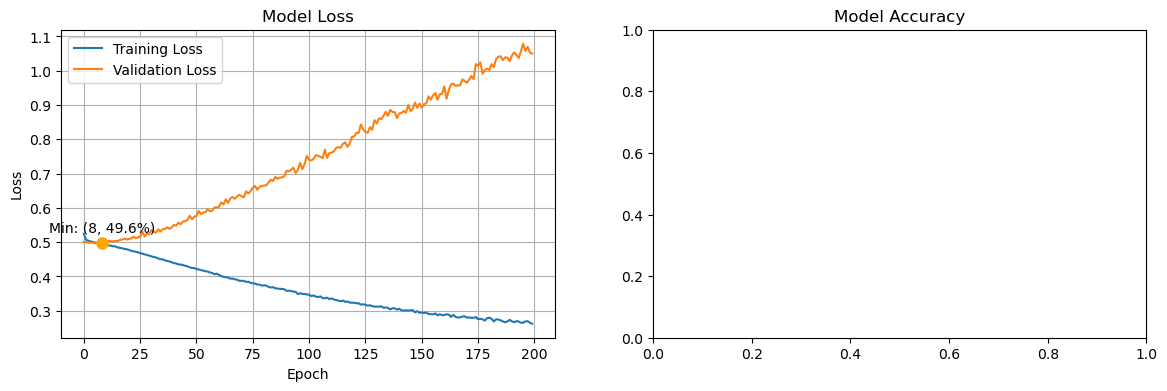

In [24]:
import matplotlib.pyplot as plt

if "histories" not in locals():
    histories = []

if len(histories) == 0 or history not in histories:
    histories.append(history)

for h in histories[::-1]:
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    plt.title("Model Loss")
    plt.plot(h["loss"], label="Training Loss")
    plt.plot(h["val_loss"], label="Validation Loss")
    y = min(h["val_loss"])
    x = h["val_loss"].index(y)
    plt.plot(
        x,
        y,
        marker="o",
        markersize=8,
        color="orange",
    )
    plt.annotate(
        f"Min: ({x}, {y * 100:.1f}%)",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.title("Model Accuracy")
    plt.plot(h["binary_accuracy"], label="Training Accuracy")
    plt.plot(h["val_binary_accuracy"], label="Validation Accuracy")
    y = max(h["val_binary_accuracy"])
    x = h["val_binary_accuracy"].index(y)
    plt.plot(
        x,
        y,
        marker="o",
        markersize=8,
        color="orange",
    )
    plt.annotate(
        f"Max: ({x}, {y * 100:.1f}%)",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()

    plt.show()

In [ ]:
# model.save("model.keras")
# with open("scaler", "w") as f:
#     f.write(" ".join(map(str, scaler.scale_.tolist())))